#                                                            AI Project

#  ---- Using Reinforcement Learning to Determine the Ideal Offer for Each Customer Type ----

📌 Scenario
A company selling electronic products wants to know the best type of discount to offer each customer segment to achieve the highest sales without reducing profits.

👥 Customer Segments (States): Low Income, Medium Income, High Income.

🎯 Actions: No Discount, 10% Discount, 20% Discoun, Holiday Discount.

🧠 Goal:
Learn the optimal strategy (best offer for each segment) based on customer behavior (buy or not), and maximize rewards (more sales + higher profits).

🧪 Reinforcement Learning Approach:

1. Environment: The customer

2. Agent: The system that proposes the offers

3. Reward: If the customer buys the product after seeing the offer ✅ (1), if not ❌ (0)

*After several trials, the system will learn that:

- Low-income customers respond best to a 20% discount

- Medium-income customers prefer a 10% discount

In [23]:
import numpy as np

# Define the environment
states = ["Low Income", "Medium Income", "High Income"]
actions = ["No Discount", "Small Discount", "Big Discount"]

# Q-table: rows are states, columns are actions
q_table = np.zeros((len(states), len(actions)))

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 1000

# Simulated reward function
def get_reward(state, action):
    if state == 0 and action == 2: return 1  # Big discount works best for low income
    if state == 2 and action == 0: return 1  # No discount works best for high income
    if state == 1 and action == 1: return 1  # Small discount for medium income
    return 0  # Otherwise, not effective

# Training loop
for ep in range(episodes):
    state = np.random.randint(0, 3)
    if np.random.rand() < epsilon:
        action = np.random.randint(0, 3)
    else:
        action = np.argmax(q_table[state])
    
    reward = get_reward(state, action)
    next_state = np.random.randint(0, 3)  # Random next state
    q_table[state, action] += alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])

# Show results
print("Q-table after training:")
print(q_table)


Q-table after training:
[[6.5269529  5.31271334 9.43155108]
 [6.67305819 9.41814962 6.99831742]
 [9.4204203  6.09212821 6.48648893]]


# Reinforcement Learning Process

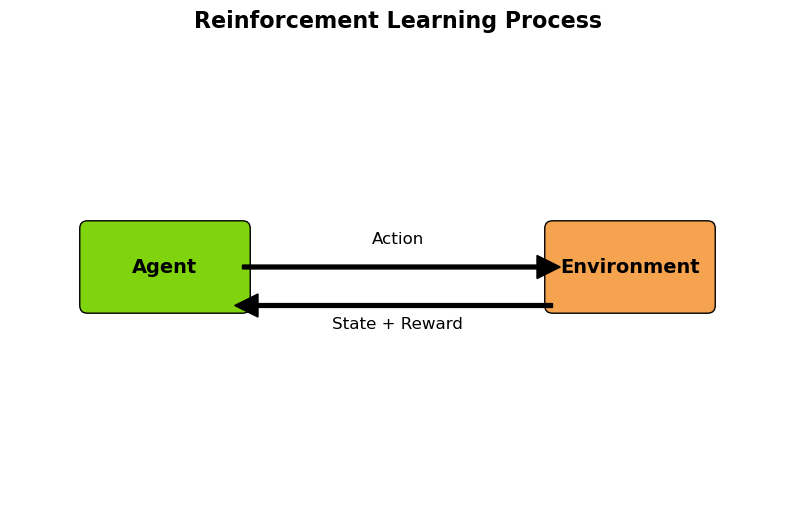

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Draw boxes
agent_box = patches.FancyBboxPatch((1, 2.5), 2, 1, boxstyle="round,pad=0.1", color="#7FD40E", ec="black")
env_box = patches.FancyBboxPatch((7, 2.5), 2, 1, boxstyle="round,pad=0.1", color="#F6A350", ec="black")

ax.add_patch(agent_box)
ax.add_patch(env_box)

# Add text
ax.text(2, 3, "Agent", ha="center", va="center", fontsize=14, weight="bold")
ax.text(8, 3, "Environment", ha="center", va="center", fontsize=14, weight="bold")

# Draw arrows
arrow1 = patches.FancyArrow(3, 3, 3.8, 0, width=0.05, head_width=0.3, head_length=0.3, color="black")
arrow2 = patches.FancyArrow(7, 2.5, -3.8, 0, width=0.05, head_width=0.3, head_length=0.3, color="black")

ax.add_patch(arrow1)
ax.add_patch(arrow2)

# Add arrow labels
ax.text(5, 3.3, "Action", ha="center", fontsize=12)
ax.text(5, 2.2, "State + Reward", ha="center", fontsize=12)

plt.title("Reinforcement Learning Process", fontsize=16, weight="bold")
plt.show()

# Marketing Discount Strategy

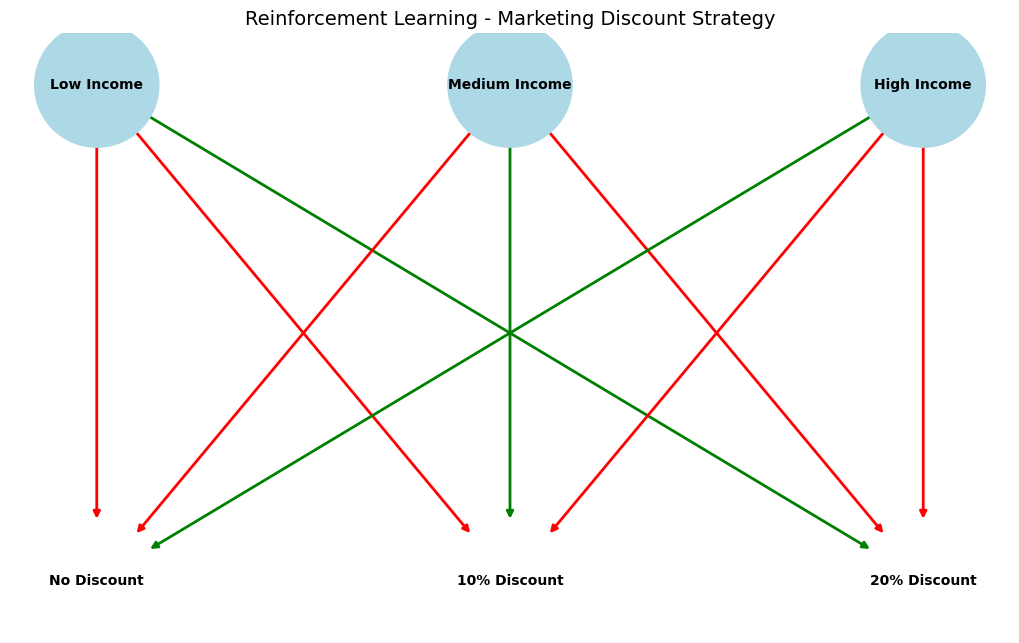

In [20]:
import matplotlib.pyplot as plt
import networkx as nx

# Define the environment and customer states (different income levels)
states = ['Low Income', 'Medium Income', 'High Income']

# Define possible actions (discounts)
actions = ['No Discount', '10% Discount', '20% Discount']

# Define the reward values based on the state and action
rewards = {
    'Low Income': {'No Discount': 0, '10% Discount': 0, '20% Discount': 1},  # Low income: best action is 20% discount
    'Medium Income': {'No Discount': 0, '10% Discount': 1, '20% Discount': 0},  # Medium income: best action is 10% discount
    'High Income': {'No Discount': 1, '10% Discount': 0, '20% Discount': 0},  # High income: best action is No Discount
}

# Create a directed graph using NetworkX
G = nx.DiGraph()

# Add nodes (states) to the graph
for state in states:
    G.add_node(state, color='lightblue')  # Color the nodes for visibility

# Add edges (actions between states) and their reward values
for state in states:
    for action in actions:
        reward = rewards[state][action]
        # Color the edges green if the reward is positive, red if the reward is zero
        G.add_edge(state, action, weight=reward, color='green' if reward == 1 else 'red')

# Set node colors based on the 'color' attribute
node_colors = [G.nodes[node].get('color', 'white') for node in G.nodes]

# Set edge colors based on the reward values
edge_colors = [G.edges[edge]['color'] for edge in G.edges]

# Set positions for the nodes to make the graph visually appealing
pos = {'Low Income': (0, 2), 'Medium Income': (2, 2), 'High Income': (4, 2),
       'No Discount': (0, 0), '10% Discount': (2, 0), '20% Discount': (4, 0)}

# Plot the graph with customized settings
plt.figure(figsize=(10, 6))  # Set figure size
nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors, node_size=8000, font_size=10, font_weight='bold', width=2)

# Add a title to the graph
plt.title("Reinforcement Learning - Marketing Discount Strategy", fontsize=14)

# Display the plot
plt.show()

# Q-Table

Final Q-table:
Low Income: [5.53991672 4.30693156 5.34022304]
Medium Income: [4.33725629 6.66918712 3.37710362]
High Income: [6.49095211 5.30193376 4.45399042]

Best strategy per income level:
Low Income → Best Offer: No Discount
Medium Income → Best Offer: 10% Discount
High Income → Best Offer: No Discount


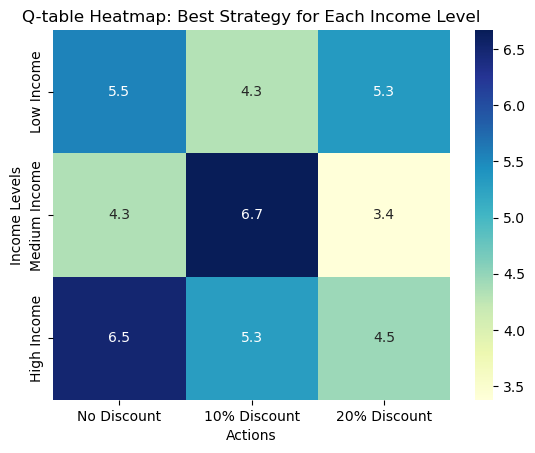

In [18]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Define states: Low, Medium, High income levels
states = ["Low Income", "Medium Income", "High Income"]
state_indices = list(range(len(states)))

# Define actions: No discount, Small discount, Big discount
actions = ["No Discount", "10% Discount", "20% Discount"]
action_indices = list(range(len(actions)))

# Initialize Q-table (3 states x 3 actions)
Q = np.zeros((len(states), len(actions)))

# Learning parameters
alpha = 0.1    # Learning rate
gamma = 0.9    # Discount factor
epsilon = 0.2  # Exploration rate
episodes = 1000  # Number of training episodes

# Reward function simulating customer behavior
def get_reward(state, action):
    if state == 0 and action == 2:  # Low income → Big discount
        return 1
    elif state == 1 and action == 1:  # Medium income → Small discount
        return 1
    elif state == 2 and action == 0:  # High income → No discount
        return 1
    else:
        return 0

# Q-learning training loop
for ep in range(episodes):
    state = random.choice(state_indices)  # Random initial state

    # Choose action using epsilon-greedy strategy
    if random.uniform(0, 1) < epsilon:
        action = random.choice(action_indices)  # Explore
    else:
        action = np.argmax(Q[state])  # Exploit

    # Get reward based on state and action
    reward = get_reward(state, action)

    # Simulate transition to a random next state
    next_state = random.choice(state_indices)
    next_max = np.max(Q[next_state])  # Max Q-value for next state

    # Q-value update using Bellman equation
    Q[state, action] += alpha * (reward + gamma * next_max - Q[state, action])

# Display final Q-table
print("Final Q-table:")
for i, row in enumerate(Q):
    print(f"{states[i]}: {row}")

# Show best action (strategy) for each income group
print("\nBest strategy per income level:")
for state in state_indices:
    best_action = np.argmax(Q[state])
    print(f"{states[state]} → Best Offer: {actions[best_action]}")

# Plotting the Q-table as a heatmap for better visualization
import seaborn as sns
sns.heatmap(Q, annot=True, cmap="YlGnBu", xticklabels=actions, yticklabels=states)
plt.title("Q-table Heatmap: Best Strategy for Each Income Level")
plt.xlabel("Actions")
plt.ylabel("Income Levels")
plt.show()


# Grouped Bar Chart

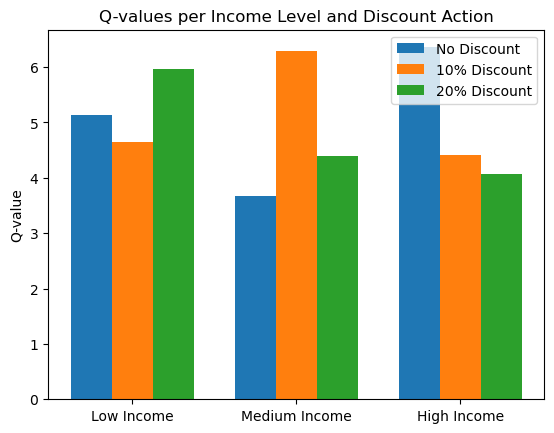

In [6]:
import matplotlib.pyplot as plt

x = np.arange(len(states))
width = 0.25

plt.bar(x - width, Q[:, 0], width, label='No Discount')
plt.bar(x, Q[:, 1], width, label='10% Discount')
plt.bar(x + width, Q[:, 2], width, label='20% Discount')

plt.xticks(x, states)
plt.ylabel("Q-value")
plt.title("Q-values per Income Level and Discount Action")
plt.legend()
plt.show()


# Heatmap

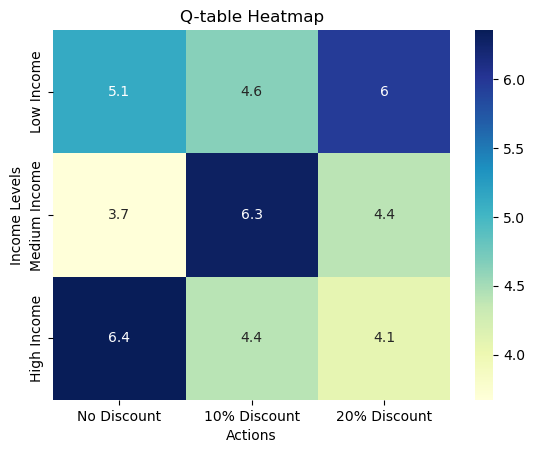

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(Q, annot=True, xticklabels=actions, yticklabels=states, cmap="YlGnBu")
plt.title("Q-table Heatmap")
plt.xlabel("Actions")
plt.ylabel("Income Levels")
plt.show()

# Q-table as Formatted Table

In [10]:
import pandas as pd
df = pd.DataFrame(Q, index=states, columns=actions)
print(df)


               No Discount  10% Discount  20% Discount
Low Income        5.129616      4.647532      5.967399
Medium Income     3.672112      6.294637      4.402011
High Income       6.357161      4.414042      4.073090


# Best Action per Income Level

In [16]:
# Labels (if not already defined)
state_labels = ["Low Income", "Medium Income", "High Income"]
action_labels = ["No Discount", "10%", "20%"]

# Loop through each state and print the best action
for i in range(len(state_labels)):
    best_action_index = np.argmax(Q[i])
    best_action = action_labels[best_action_index]
    print(f"{state_labels[i]} → Best offer: {best_action}")

Low Income → Best offer: 20%
Medium Income → Best offer: 10%
High Income → Best offer: No Discount


# ----------------------------------------